# Penerapan Random Forest dan K-Means Clustering untuk Analisis Data Sensor IoT pada Smart Farming Budidaya Tomat

**Dataset:** IoT-based Data Collection in a Tomato Cultivation Under Different Irrigation Regimes (Mendeley Data)
**Mata Kuliah:** Data Mining — Sistem Informasi


**IMPORT LIBRARY**

In [1]:
# Manajemen file
import os

# DataFrame & komputasi numerik
import pandas as pd
import numpy as np

# Visualisasi
import matplotlib.pyplot as plt
import seaborn as sns

# Preprocessing & Machine Learning
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score


**PERSIAPAN DATASET**

Upload 3 file CSV mentah (`stuard_environmental_data.csv`, `stuard_soil_data.csv`, `stuard_water_meter_data.csv`)
ke folder Google Collab "/content" sebelum menjalankan cell di bawah.

In [25]:
# Load 3 file CSV mentah
base_path = "/content"

env_raw   = pd.read_csv(f"{base_path}/stuard_environmental_data.csv")
soil_raw  = pd.read_csv(f"{base_path}/stuard_soil_data.csv")
water_raw = pd.read_csv(f"{base_path}/stuard_water_meter_data.csv")

print(f"Environmental : {env_raw.shape}")
print(f"Soil          : {soil_raw.shape}")
print(f"Water Meter   : {water_raw.shape}")

Environmental : (10964, 8)
Soil          : (32668, 8)
Water Meter   : (32649, 5)


**PEMBERSIHAN DATA**

Catatan: pada file `soil` dan `water_meter`, ditemukan baris header yang terduplikasi di tengah data
(kemungkinan akibat penggabungan 3 file per-line menjadi 1 file tanpa membuang header masing-masing).
Baris ini harus dibuang sebelum data dapat diproses lebih lanjut.

In [4]:
# Buang baris header yang nyelip (kolom 'id' isinya literal teks "id", bukan angka)
soil_clean  = soil_raw[soil_raw['id'] != 'id'].copy()
water_clean = water_raw[water_raw['id'] != 'id'].copy()
env_clean   = env_raw.copy()

print(f"Soil sebelum  : {len(soil_raw)}  -> sesudah: {len(soil_clean)}")
print(f"Water sebelum : {len(water_raw)} -> sesudah: {len(water_clean)}")


Soil sebelum  : 32668  -> sesudah: 32666
Water sebelum : 32649 -> sesudah: 32647


In [5]:
# Perbaiki tipe data (sempat terbaca sebagai teks akibat baris header yang nyelip)
soil_clean['line'] = soil_clean['line'].astype(int)
soil_clean['ts_generation'] = soil_clean['ts_generation'].astype('int64')
for col in ['electrical_conductivity', 'humidity', 'temperature']:
    soil_clean[col] = pd.to_numeric(soil_clean[col], errors='coerce')

water_clean['line'] = water_clean['line'].astype(int)
water_clean['ts_generation'] = water_clean['ts_generation'].astype('int64')
water_clean['current_volume'] = pd.to_numeric(water_clean['current_volume'], errors='coerce')

env_clean['ts_generation'] = env_clean['ts_generation'].astype('int64')

# Konversi timestamp (epoch ms) -> format waktu yang bisa dibaca
env_clean['waktu']   = pd.to_datetime(env_clean['ts_generation'], unit='ms')
soil_clean['waktu']  = pd.to_datetime(soil_clean['ts_generation'], unit='ms')
water_clean['waktu'] = pd.to_datetime(water_clean['ts_generation'], unit='ms')

print("Rentang waktu data:")
print(f"  Environmental : {env_clean['waktu'].min()} s/d {env_clean['waktu'].max()}")
print(f"  Soil          : {soil_clean['waktu'].min()} s/d {soil_clean['waktu'].max()}")


Rentang waktu data:
  Environmental : 2023-06-29 06:14:46.484000 s/d 2023-09-13 21:51:25.121000
  Soil          : 2023-06-28 22:09:25.881000 s/d 2023-09-13 21:59:05.445000


**PENGGABUNGAN DATA (MERGE)**

Timestamp antar sensor tidak sama persis (selisih beberapa detik), sehingga penggabungan tidak bisa
menggunakan `merge()` biasa (yang mensyaratkan nilai identik). Digunakan `merge_asof()` yang mencari
pasangan waktu **terdekat**, dengan toleransi maksimal 10 menit.

In [6]:
# Rename kolom agar tidak tertukar (soil & environmental sama-sama punya 'temperature', 'humidity')
soil_renamed = soil_clean.rename(columns={
    'temperature': 'soil_temperature',
    'humidity': 'soil_humidity',
    'electrical_conductivity': 'soil_ec'
})
env_renamed = env_clean.rename(columns={
    'temperature': 'air_temperature',
    'humidity': 'air_humidity'
})

# WAJIB diurutkan berdasarkan waktu sebelum merge_asof
soil_sorted = soil_renamed.sort_values('waktu').reset_index(drop=True)
env_sorted  = env_renamed.sort_values('waktu').reset_index(drop=True)

# Gabungkan: tiap baris soil dicarikan baris environmental dengan waktu PALING DEKAT
merged = pd.merge_asof(
    soil_sorted[['waktu', 'line', 'soil_ec', 'soil_humidity', 'soil_temperature']],
    env_sorted[['waktu', 'co2', 'air_humidity', 'pressure', 'air_temperature']],
    on='waktu', direction='nearest', tolerance=pd.Timedelta('10min')
)

# Buang baris yang gagal menemukan pasangan (di luar toleransi 10 menit)
df = merged.dropna().reset_index(drop=True)

print(f"Total baris setelah merge : {len(merged)}")
print(f"Total baris setelah dropna: {len(df)}  (baris gagal match: {merged['air_temperature'].isna().sum()})")
print(f"\nDistribusi data per Line:")
print(df['line'].value_counts().sort_index())

df.to_csv('dataset_final_tomat_irigasi.csv', index=False)


Total baris setelah merge : 32666
Total baris setelah dropna: 32579  (baris gagal match: 87)

Distribusi data per Line:
line
1    10879
2    10862
3    10838
Name: count, dtype: int64


**EKSPLORASI DATA**

In [7]:
feature_cols = ['soil_ec', 'soil_humidity', 'soil_temperature', 'co2', 'air_humidity', 'pressure', 'air_temperature']

print("Statistik Deskriptif:")
print(df[feature_cols].describe().round(2))

print("\nCek Missing Value:")
print(df[feature_cols].isnull().sum())


Statistik Deskriptif:
        soil_ec  soil_humidity  soil_temperature       co2  air_humidity  \
count  32579.00       32579.00          32579.00  32579.00      32579.00   
mean     374.52          25.78             23.98    481.43         58.11   
std      274.95           7.60              2.06     48.03         18.22   
min        0.00           0.00             19.60    396.00         18.00   
25%      169.00          20.75             22.60    448.00         42.50   
50%      295.00          23.41             23.80    470.00         57.50   
75%      464.00          28.22             25.10    503.00         74.00   
max     1767.00          56.81             32.60    858.00         97.00   

       pressure  air_temperature  
count  32579.00         32579.00  
mean    1009.79            26.91  
std        5.25             7.23  
min      993.70            10.10  
25%     1006.70            20.80  
50%     1010.50            26.10  
75%     1013.60            33.10  
max     1019.

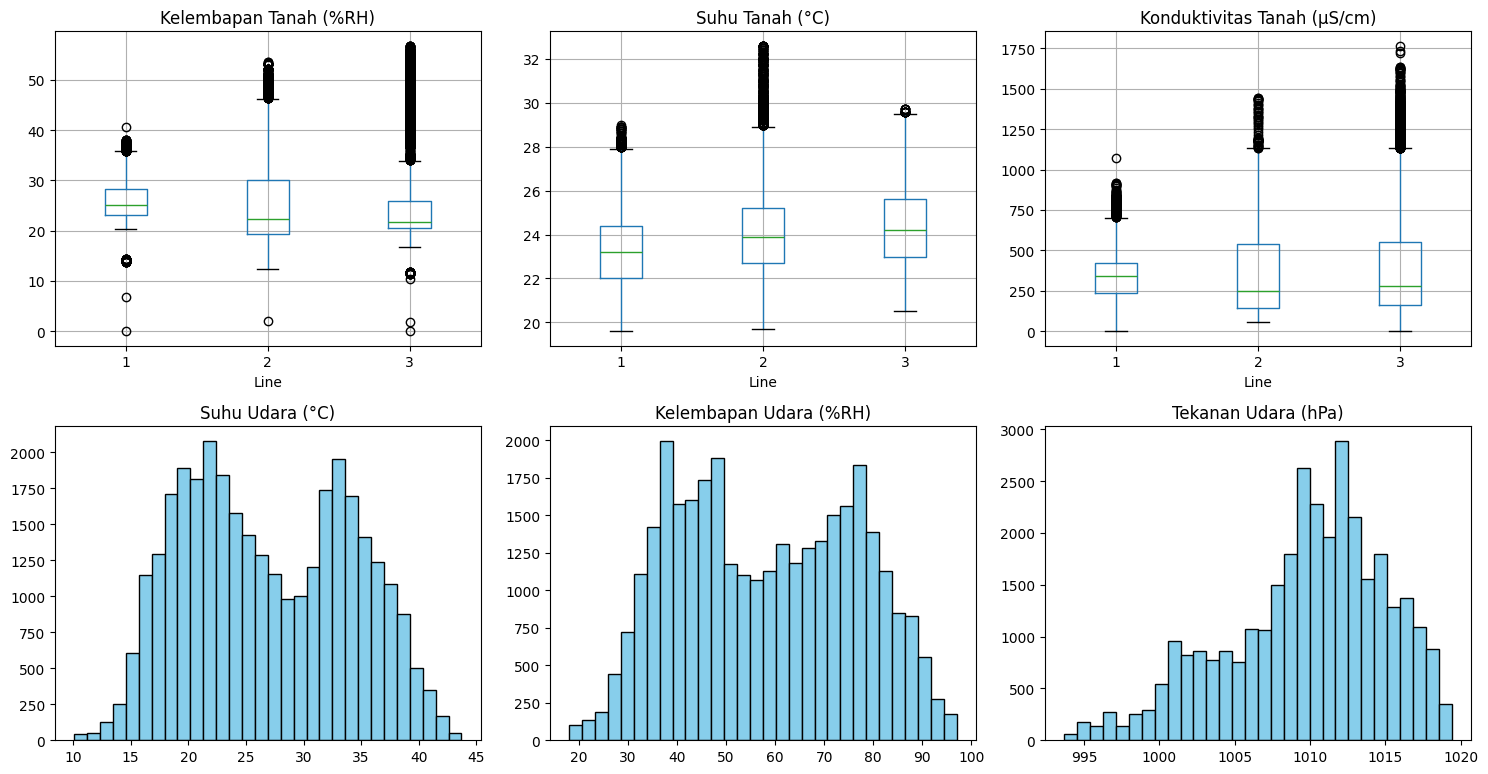

In [8]:
# Boxplot fitur TANAH per Line, dan histogram fitur UDARA
fig, axes = plt.subplots(2, 3, figsize=(15, 8))

soil_feats  = ['soil_humidity', 'soil_temperature', 'soil_ec']
soil_titles = ['Kelembapan Tanah (%RH)', 'Suhu Tanah (°C)', 'Konduktivitas Tanah (µS/cm)']
for i, (f, t) in enumerate(zip(soil_feats, soil_titles)):
    df.boxplot(column=f, by='line', ax=axes[0, i])
    axes[0, i].set_title(t)
    axes[0, i].set_xlabel('Line')
    axes[0, i].get_figure().suptitle('')

air_feats  = ['air_temperature', 'air_humidity', 'pressure']
air_titles = ['Suhu Udara (°C)', 'Kelembapan Udara (%RH)', 'Tekanan Udara (hPa)']
for i, (f, t) in enumerate(zip(air_feats, air_titles)):
    axes[1, i].hist(df[f], bins=30, color='skyblue', edgecolor='black')
    axes[1, i].set_title(t)

plt.tight_layout()
plt.show()


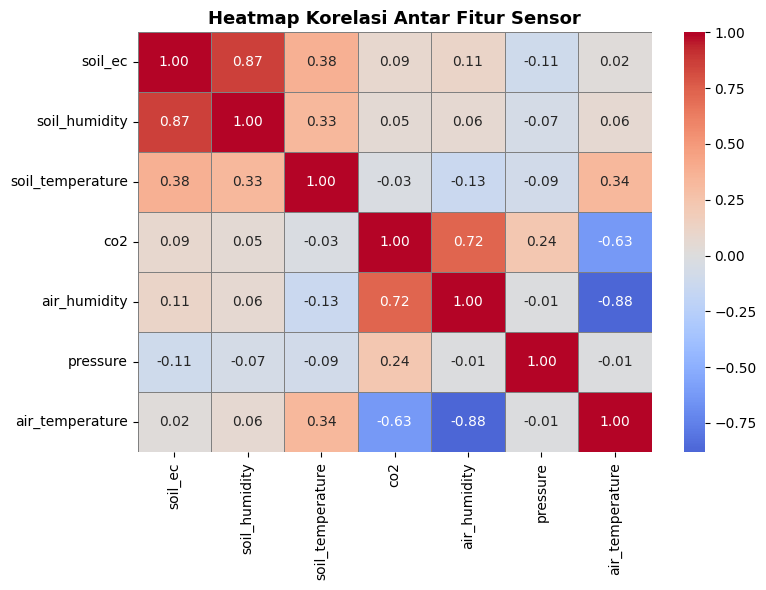

In [9]:
# Heatmap korelasi antar fitur sensor
plt.figure(figsize=(8, 6))
corr_matrix = df[feature_cols].corr()
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', center=0,
            linewidths=0.5, linecolor='gray', annot_kws={"size": 10})
plt.title("Heatmap Korelasi Antar Fitur Sensor", fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()


**UNSUPERVISED LEARNING: K-MEANS CLUSTERING**

Pada tahap ini, kolom `line` (label Line irigasi) **tidak digunakan** sebagai input.
Model hanya melihat 7 fitur sensor dan mencari pengelompokan alami berdasarkan kemiripan data.
Label `line` baru dibuka kembali di akhir, untuk membandingkan hasil clustering dengan kondisi Line asli.

In [10]:
X = df[feature_cols]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)


**Optimasi Jumlah Cluster — Silhouette Score**

Digunakan Silhouette Score (bukan Elbow Method) karena memberikan ukuran kuantitatif yang lebih
objektif untuk menilai kualitas pemisahan cluster pada setiap nilai K.

In [11]:
silhouette_values = []
K_range = range(2, 11)

print("Menghitung Silhouette Score untuk K=2 sampai K=10...")
print("(sample_size=5000 digunakan agar komputasi tetap efisien pada data berukuran besar)\n")

for k in K_range:
    kmeans_temp = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels_temp = kmeans_temp.fit_predict(X_scaled)
    sil_score = silhouette_score(X_scaled, labels_temp, sample_size=5000, random_state=42)
    silhouette_values.append(sil_score)
    print(f"  K={k:2d} | Silhouette Score: {sil_score:.4f}")

best_k = list(K_range)[np.argmax(silhouette_values)]
print(f"\nK dengan Silhouette Score tertinggi: K={best_k} (score={max(silhouette_values):.4f})")


Menghitung Silhouette Score untuk K=2 sampai K=10...
(sample_size=5000 digunakan agar komputasi tetap efisien pada data berukuran besar)

  K= 2 | Silhouette Score: 0.2615
  K= 3 | Silhouette Score: 0.2868
  K= 4 | Silhouette Score: 0.2660
  K= 5 | Silhouette Score: 0.2704
  K= 6 | Silhouette Score: 0.2287
  K= 7 | Silhouette Score: 0.2164
  K= 8 | Silhouette Score: 0.2184
  K= 9 | Silhouette Score: 0.2216
  K=10 | Silhouette Score: 0.2125

K dengan Silhouette Score tertinggi: K=3 (score=0.2868)


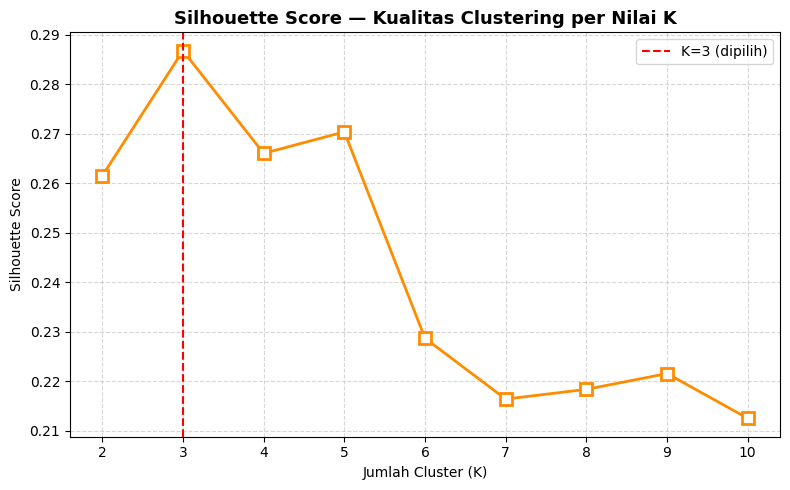

In [12]:
plt.figure(figsize=(8, 5))
plt.plot(list(K_range), silhouette_values, marker='s', color='darkorange',
         linewidth=2, markersize=8, markerfacecolor='white', markeredgewidth=2)
plt.axvline(x=best_k, color='red', linestyle='--', linewidth=1.5, label=f'K={best_k} (dipilih)')
plt.title("Silhouette Score — Kualitas Clustering per Nilai K", fontsize=13, fontweight='bold')
plt.xlabel("Jumlah Cluster (K)")
plt.ylabel("Silhouette Score")
plt.xticks(list(K_range))
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()


**Catatan pemilihan K:** Nilai K dengan Silhouette Score tertinggi pada eksperimen ini **kebetulan sama**
dengan jumlah Line irigasi pada dataset (3 Line), sehingga K=3 dipilih baik atas dasar pertimbangan
statistik maupun domain (sesuai jumlah kategori rezim irigasi yang diteliti).

In [13]:
kmeans = KMeans(n_clusters=best_k, random_state=42, n_init=10)
cluster_labels = kmeans.fit_predict(X_scaled)
df['Cluster'] = cluster_labels

final_silhouette = silhouette_score(X_scaled, cluster_labels, sample_size=5000, random_state=42)
print(f"Silhouette Score final (K={best_k}): {final_silhouette:.4f}")

print("\nDistribusi jumlah data per cluster:")
print(df['Cluster'].value_counts().sort_index())


Silhouette Score final (K=3): 0.2868

Distribusi jumlah data per cluster:
Cluster
0    13665
1    14036
2     4878
Name: count, dtype: int64


**Membandingkan hasil Clustering dengan Label Line asli**

In [14]:
cluster_analysis = pd.crosstab(df['line'], df['Cluster'], margins=True, margins_name='Total')
print("Cross-tabulation: Line Irigasi vs Cluster")
print(cluster_analysis)


Cross-tabulation: Line Irigasi vs Cluster
Cluster      0      1     2  Total
line                              
1         5195   5529   155  10879
2         4297   3963  2602  10862
3         4173   4544  2121  10838
Total    13665  14036  4878  32579


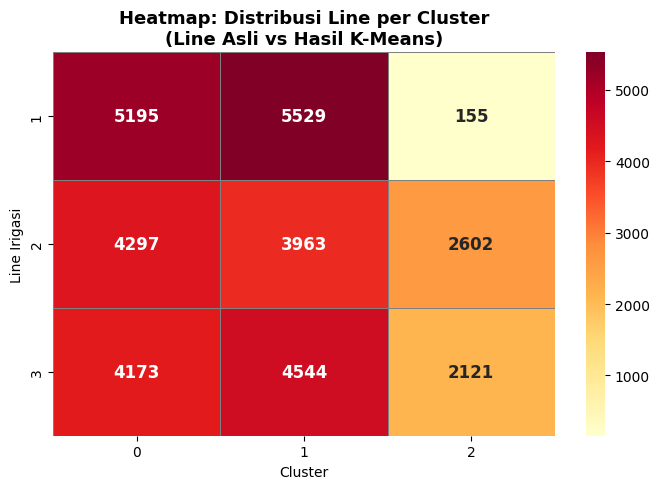

In [15]:
crosstab_plain = pd.crosstab(df['line'], df['Cluster'])
plt.figure(figsize=(7, 5))
sns.heatmap(crosstab_plain, annot=True, fmt='d', cmap='YlOrRd', linewidths=0.5,
            linecolor='gray', annot_kws={"size": 12, "weight": "bold"})
plt.title("Heatmap: Distribusi Line per Cluster\n(Line Asli vs Hasil K-Means)", fontsize=13, fontweight='bold')
plt.xlabel("Cluster")
plt.ylabel("Line Irigasi")
plt.tight_layout()
plt.show()


In [16]:
# Rata-rata fitur tiap cluster -- membantu interpretasi karakteristik tiap cluster
print("Rata-rata fitur sensor per Cluster:")
print(df.groupby('Cluster')[feature_cols].mean().round(2))


Rata-rata fitur sensor per Cluster:
         soil_ec  soil_humidity  soil_temperature     co2  air_humidity  \
Cluster                                                                   
0         297.01          23.46             23.38  514.56         74.34   
1         276.23          23.17             23.74  449.09         42.53   
2         874.52          39.78             26.34  481.64         57.48   

         pressure  air_temperature  
Cluster                             
0         1010.16            20.31  
1         1009.34            32.67  
2         1010.05            28.80  


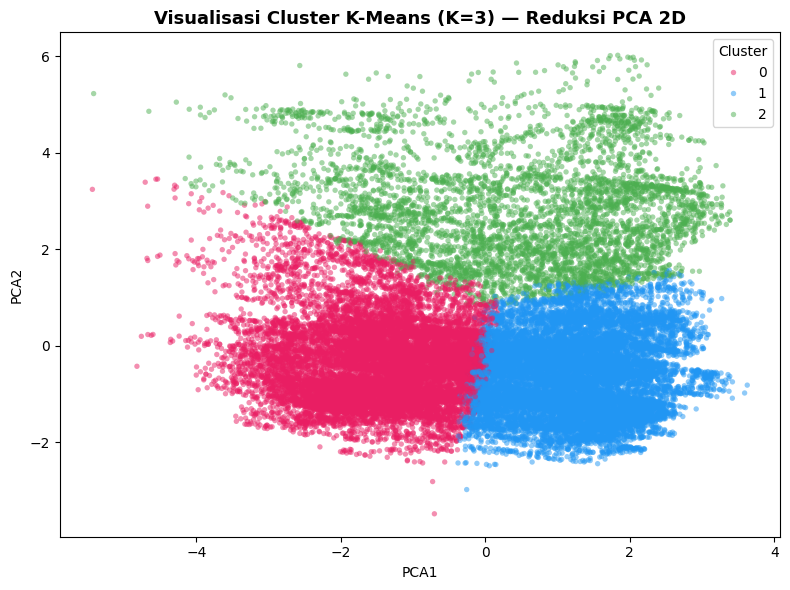

Variansi yang dijelaskan: PC1=36.62%, PC2=30.42%


In [17]:
# Visualisasi cluster dengan reduksi dimensi PCA (7D -> 2D)
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)
df_pca = pd.DataFrame({'PCA1': X_pca[:, 0], 'PCA2': X_pca[:, 1], 'Cluster': df['Cluster']})

plt.figure(figsize=(8, 6))
sns.scatterplot(data=df_pca, x='PCA1', y='PCA2', hue='Cluster',
                 palette={0: "#E91E63", 1: "#2196F3", 2: "#4CAF50"},
                 s=15, alpha=0.5, edgecolor='none')
plt.title(f"Visualisasi Cluster K-Means (K={best_k}) — Reduksi PCA 2D", fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print(f"Variansi yang dijelaskan: PC1={pca.explained_variance_ratio_[0]:.2%}, PC2={pca.explained_variance_ratio_[1]:.2%}")


**SUPERVISED LEARNING: RANDOM FOREST**

Berbeda dengan tahap sebelumnya, pada tahap ini label `line` **digunakan** sebagai target (y) yang
ingin diprediksi model berdasarkan 7 fitur sensor (X).

In [18]:
y = df['line']

print(f"Shape X (fitur) : {X.shape}")
print(f"Shape y (label) : {y.shape}")
print(f"Distribusi label:\n{y.value_counts().sort_index()}")


Shape X (fitur) : (32579, 7)
Shape y (label) : (32579,)
Distribusi label:
line
1    10879
2    10862
3    10838
Name: count, dtype: int64


In [19]:
# Train-Test Split (80% train, 20% test, stratified)
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, stratify=y, random_state=42
)

print(f"Data Training : {X_train.shape[0]} sampel")
print(f"Data Testing  : {X_test.shape[0]} sampel")


Data Training : 26063 sampel
Data Testing  : 6516 sampel


In [20]:
rf = RandomForestClassifier(n_estimators=200, max_depth=10, random_state=42)

# 5-Fold Cross Validation pada data training
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_scores = cross_val_score(rf, X_train, y_train, cv=cv, scoring='accuracy')

print(f"Akurasi tiap fold : {[round(s, 4) for s in cv_scores]}")
print(f"Rata-rata Akurasi : {cv_scores.mean():.4f} ± {cv_scores.std():.4f}")


Akurasi tiap fold : [np.float64(0.9141), np.float64(0.9075), np.float64(0.9179), np.float64(0.9114), np.float64(0.9183)]
Rata-rata Akurasi : 0.9138 ± 0.0040


In [21]:
rf.fit(X_train, y_train)
y_pred = rf.predict(X_test)

print(f"Test Accuracy: {accuracy_score(y_test, y_pred):.4f}\n")
print("Classification Report:")
print(classification_report(y_test, y_pred, digits=4))


Test Accuracy: 0.9084

Classification Report:
              precision    recall  f1-score   support

           1     0.8367    0.9775    0.9017      2176
           2     0.9526    0.8697    0.9093      2172
           3     0.9558    0.8778    0.9151      2168

    accuracy                         0.9084      6516
   macro avg     0.9150    0.9083    0.9087      6516
weighted avg     0.9150    0.9084    0.9087      6516



Feature Importance:
           Fitur  Importance
   soil_humidity    0.409879
         soil_ec    0.302662
soil_temperature    0.135499
        pressure    0.080408
 air_temperature    0.030092
    air_humidity    0.027412
             co2    0.014048


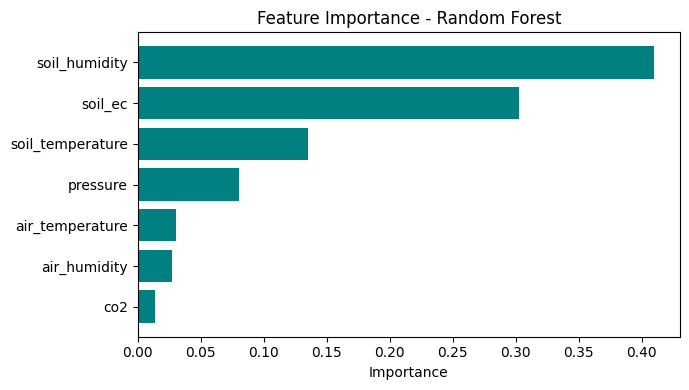

In [22]:
importance_df = pd.DataFrame({
    'Fitur': feature_cols,
    'Importance': rf.feature_importances_
}).sort_values('Importance', ascending=False).reset_index(drop=True)

print("Feature Importance:")
print(importance_df.to_string(index=False))

plt.figure(figsize=(7, 4))
plt.barh(importance_df['Fitur'], importance_df['Importance'], color='teal')
plt.xlabel('Importance')
plt.title('Feature Importance - Random Forest')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()


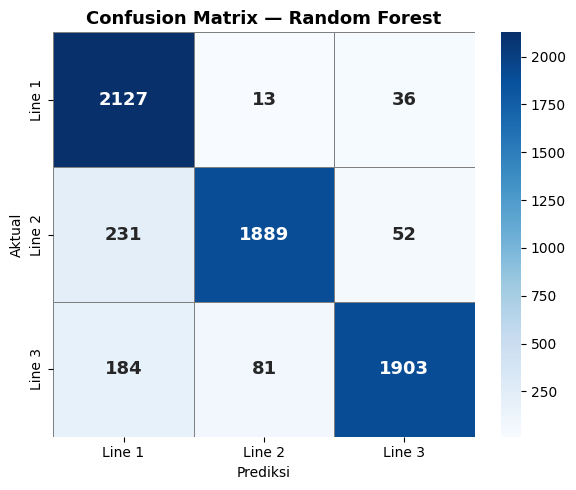

In [23]:
cm = confusion_matrix(y_test, y_pred, labels=rf.classes_)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=[f'Line {c}' for c in rf.classes_],
            yticklabels=[f'Line {c}' for c in rf.classes_],
            linewidths=0.5, linecolor='gray', annot_kws={"size": 13, "weight": "bold"})
plt.xlabel("Prediksi")
plt.ylabel("Aktual")
plt.title("Confusion Matrix — Random Forest", fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()


**RINGKASAN**

In [24]:
print("RINGKASAN HASIL")
print(f"  Total data diproses        : {len(df):,} baris")
print(f"  Fitur yang digunakan       : {len(feature_cols)} ({', '.join(feature_cols)})")
print(f"  K terpilih (K-Means)       : {best_k}")
print(f"  Silhouette Score (K={best_k})     : {final_silhouette:.4f}")
print(f"  CV Accuracy (Random Forest): {cv_scores.mean():.4f}")
print(f"  Test Accuracy (Random Forest): {accuracy_score(y_test, y_pred):.4f}")


RINGKASAN HASIL
  Total data diproses        : 32,579 baris
  Fitur yang digunakan       : 7 (soil_ec, soil_humidity, soil_temperature, co2, air_humidity, pressure, air_temperature)
  K terpilih (K-Means)       : 3
  Silhouette Score (K=3)     : 0.2868
  CV Accuracy (Random Forest): 0.9138
  Test Accuracy (Random Forest): 0.9084
